# Transformer Mimarisi (Sıfırdan Uygulama + Çeviri Görevi)

Bu notebook, Transformer mimarisini sıfırdan uygulamakta ve basit bir sequence-to-sequence görevi (sayı dizisi ters çevirme) ile test etmektedir.

**Kapsanan Konular:**
1. Sinüsözel Konumsal Kodlama
2. Multi-Head Self-Attention
3. Feed-Forward Network
4. Encoder ve Decoder Blokları
5. Tam Transformer Modeli
6. Veri Hazırlığı: Basit Çeviri Görevi
7. Eğitim
8. Greedy Decoding ile Çıkarım
9. Attention Görselleştirilmesi

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import math
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Cihaz seçimi
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Kullanılan cihaz: {device}')
print(f'PyTorch versiyonu: {torch.__version__}')

Kullanılan cihaz: cpu
PyTorch versiyonu: 2.11.0+cpu


## 1. Sinüsözel Konumsal Kodlama

Transformer modelleri sıralı veri işlemediği için, pozisyon bilgisini eklemek gerekir.

$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

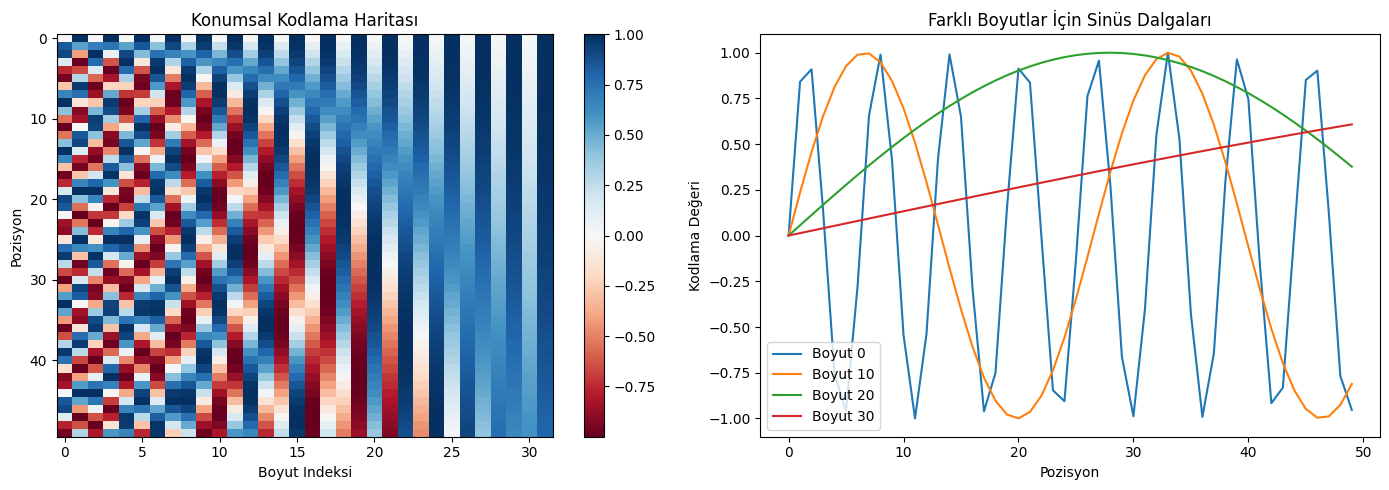

Konumsal kodlama boyutu: (100, 64)


In [2]:
class PositionalEncoding(nn.Module):
    """Sinüsözel konumsal kodlama"""

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Konumsal kodlama matrisi oluştur
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Sin ve cos değerlerini hesapla
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)

        self.register_buffer('pe', pe)

    def forward(self, x):
        """x: (batch_size, seq_len, d_model)"""
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# Konumsal kodlamayı görselleştir
d_model = 64
pe_module = PositionalEncoding(d_model, max_len=100, dropout=0.0)
pe_values = pe_module.pe.squeeze(0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Konumsal kodlama haritası
im = axes[0].imshow(pe_values[:50, :32], aspect='auto', cmap='RdBu')
axes[0].set_xlabel('Boyut Indeksi')
axes[0].set_ylabel('Pozisyon')
axes[0].set_title('Konumsal Kodlama Haritası')
plt.colorbar(im, ax=axes[0])

# Bazı boyutlar için sinüs dalgaları
positions = np.arange(50)
for dim in [0, 10, 20, 30]:
    axes[1].plot(positions, pe_values[:50, dim], label=f'Boyut {dim}')
axes[1].set_xlabel('Pozisyon')
axes[1].set_ylabel('Kodlama Değeri')
axes[1].set_title('Farklı Boyutlar İçin Sinüs Dalgaları')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Konumsal kodlama boyutu: {pe_values.shape}')

## 2. Multi-Head Self-Attention

Self-Attention mekanizması, her pozisyonun tüm diğer pozisyonlarla ilişki kurmasını sağlar.

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Multi-Head Attention, farklı "bakış açılarıyla" dikkat hesaplar.

Girdi boyutu: torch.Size([1, 10, 64])
Çıkış boyutu: torch.Size([1, 10, 64])
Dikkat ağırlıkları boyutu: torch.Size([1, 4, 10, 10])


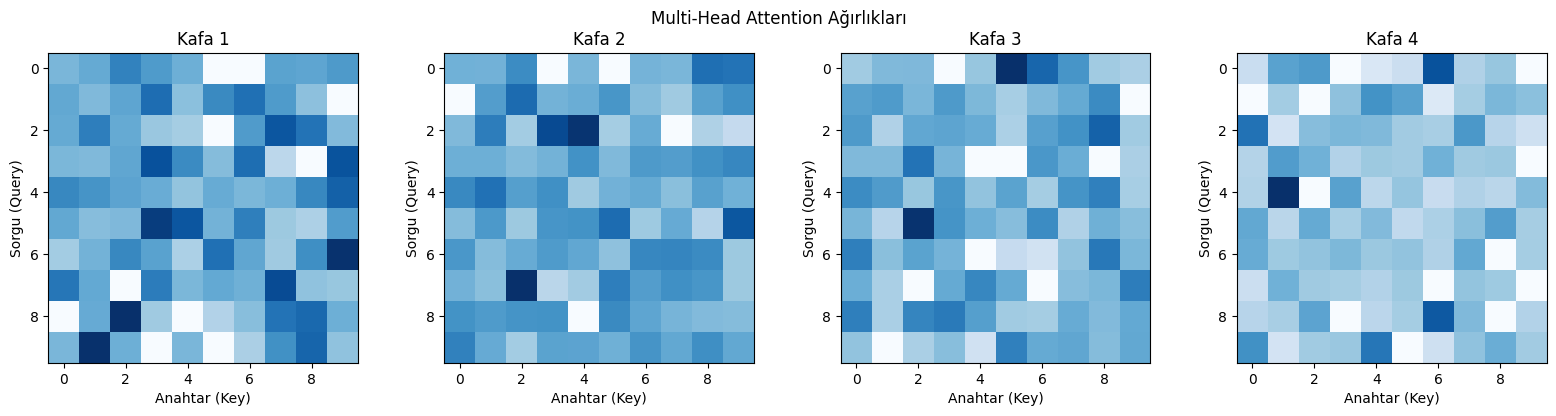

In [3]:
class MultiHeadAttention(nn.Module):
    """Çoklu Kafa Dikkat Mekanizması"""

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model num_heads'a bölünmelidir"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Q, K, V projeksiyonları
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.d_k)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """Ölçeklenmiş çarpım tabanlı dikkat"""
        # QK^T / sqrt(d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        # Mask uygula (varsa)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # Softmax
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # V ile çarp
        output = torch.matmul(attn_weights, V)

        return output, attn_weights

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        # 1) Q, K, V projeksiyonları
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 2) Dikkat hesapla
        attn_output, attn_weights = self.scaled_dot_product_attention(Q, K, V, mask)

        # 3) Kafaları birleştir
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # 4) Çıkış projeksiyonu
        output = self.W_o(attn_output)

        return output, attn_weights

# Attention ağırlıklarını görselleştir
d_model = 64
num_heads = 4
seq_len = 10
batch_size = 1

mha = MultiHeadAttention(d_model, num_heads)

# Rastgele girdi
x = torch.randn(batch_size, seq_len, d_model)
output, attn_weights = mha(x, x, x)  # Self-attention

print(f'Girdi boyutu: {x.shape}')
print(f'Çıkış boyutu: {output.shape}')
print(f'Dikkat ağırlıkları boyutu: {attn_weights.shape}')

# Attention ağırlıklarını görselleştir
fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))
for i in range(num_heads):
    axes[i].imshow(attn_weights[0, i].detach().numpy(), cmap='Blues')
    axes[i].set_title(f'Kafa {i+1}')
    axes[i].set_xlabel('Anahtar (Key)')
    axes[i].set_ylabel('Sorgu (Query)')

plt.suptitle('Multi-Head Attention Ağırlıkları')
plt.tight_layout()
plt.show()

## 3. Feed-Forward Network

Her attention bloğundan sonra, bağımsız olarak uygulanan bir feed-forward ağı bulunur.

$$\text{FFN}(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

In [4]:
class PositionwiseFeedForward(nn.Module):
    """Pozisyon bazlı ileri besleme ağı"""

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

# Test et
d_model = 64
d_ff = 256

ffn = PositionwiseFeedForward(d_model, d_ff)
x = torch.randn(1, 10, d_model)
output = ffn(x)

print(f'Girdi boyutu: {x.shape}')
print(f'Çıkış boyutu: {output.shape}')
print(f'\nFFN Parametreleri: {sum(p.numel() for p in ffn.parameters()):,}')

Girdi boyutu: torch.Size([1, 10, 64])
Çıkış boyutu: torch.Size([1, 10, 64])

FFN Parametreleri: 33,088


## 4. Encoder ve Decoder Blokları

### Encoder Bloğu:
- Multi-Head Self-Attention
- Feed-Forward Network
- Her katmanda Layer Normalization ve Residual Connections

### Decoder Bloğu:
- Masked Multi-Head Self-Attention
- Multi-Head Cross-Attention (Encoder-Decoder)
- Feed-Forward Network
- Layer Normalization ve Residual Connections

In [5]:
class EncoderLayer(nn.Module):
    """Tek bir Encoder katmanı"""

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-Attention + Residual + LayerNorm
        attn_output, _ = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout1(attn_output))

        # Feed-Forward + Residual + LayerNorm
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_output))

        return x

class DecoderLayer(nn.Module):
    """Tek bir Decoder katmanı"""

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        # Masked Self-Attention
        attn_output, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout1(attn_output))

        # Cross-Attention (Encoder-Decoder)
        attn_output, _ = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout2(attn_output))

        # Feed-Forward
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout3(ff_output))

        return x

class TransformerEncoder(nn.Module):
    """Tam Encoder"""

    def __init__(self, num_layers, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        for layer in self.layers:
            x = layer(x, mask)
        return x

class TransformerDecoder(nn.Module):
    """Tam Decoder"""

    def __init__(self, num_layers, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_output, src_mask=None, tgt_mask=None):
        for layer in self.layers:
            x = layer(x, enc_output, src_mask, tgt_mask)
        return x

# Test et
d_model = 64
num_heads = 4
d_ff = 256
num_layers = 2

encoder = TransformerEncoder(num_layers, d_model, num_heads, d_ff)
decoder = TransformerDecoder(num_layers, d_model, num_heads, d_ff)

x = torch.randn(1, 10, d_model)
enc_output = encoder(x)
dec_output = decoder(torch.randn(1, 5, d_model), enc_output)

print(f'Encoder Çıkış: {enc_output.shape}')
print(f'Decoder Çıkış: {dec_output.shape}')

Encoder Çıkış: torch.Size([1, 10, 64])
Decoder Çıkış: torch.Size([1, 5, 64])


## 5. Tam Transformer Modeli

Encoder-Decoder Transformer modelini tam olarak oluşturuyoruz.

### Maskeleme:
- **Source Mask:** Padding token'larını gizler
- **Target Mask:** Gelecek token'ları gizler (causal masking)

In [6]:
class Transformer(nn.Module):
    """Tam Encoder-Decoder Transformer"""

    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=128, num_heads=8,
                 num_encoder_layers=3, num_decoder_layers=3, d_ff=512, dropout=0.1):
        super().__init__()

        self.d_model = d_model

        # Embedding katmanları
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)

        # Konumsal kodlama
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout)

        # Encoder ve Decoder
        self.encoder = TransformerEncoder(num_encoder_layers, d_model, num_heads, d_ff, dropout)
        self.decoder = TransformerDecoder(num_decoder_layers, d_model, num_heads, d_ff, dropout)

        # Çıkış projeksiyonu
        self.output_proj = nn.Linear(d_model, tgt_vocab_size)

        # Ağırlık paylaşımı
        self.scale = math.sqrt(d_model)

    def generate_mask(self, src, tgt):
        """Maske oluşturur"""
        # Source mask (padding için)
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)

        # Target mask (causal + padding)
        tgt_len = tgt.size(1)
        tgt_mask = torch.tril(torch.ones(tgt_len, tgt_len, device=tgt.device)).bool()
        tgt_mask = tgt_mask.unsqueeze(0).unsqueeze(0)

        return src_mask, tgt_mask

    def forward(self, src, tgt):
        """İleri besleme"""
        src_mask, tgt_mask = self.generate_mask(src, tgt)

        # Embedding + Konumsal Kodlama
        src_emb = self.positional_encoding(self.src_embedding(src) * self.scale)
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt) * self.scale)

        # Encoder
        enc_output = self.encoder(src_emb, src_mask)

        # Decoder
        dec_output = self.decoder(tgt_emb, enc_output, src_mask, tgt_mask)

        # Çıkış projeksiyonu
        output = self.output_proj(dec_output)

        return output

# Modeli test et
src_vocab_size = 20
tgt_vocab_size = 20

model = Transformer(
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    d_model=64,
    num_heads=4,
    num_encoder_layers=2,
    num_decoder_layers=2,
    d_ff=128,
    dropout=0.1
)

# Test verisi
src = torch.randint(1, src_vocab_size, (2, 10))
tgt = torch.randint(1, tgt_vocab_size, (2, 8))

output = model(src, tgt)
print(f'Kaynak girdi: {src.shape}')
print(f'Hedef girdi: {tgt.shape}')
print(f'Model çıkışı: {output.shape}')
print(f'\nToplam parametre: {sum(p.numel() for p in model.parameters()):,}')

Kaynak girdi: torch.Size([2, 10])
Hedef girdi: torch.Size([2, 8])
Model çıkışı: torch.Size([2, 8, 20])

Toplam parametre: 171,284


## 6. Veri Hazırlığı: Basit Çeviri Görevi

Basit bir sayı dizisi ters çevirme görevi oluşturuyoruz.

**Görev:** `[1, 2, 3, 4, 5]` -> `[5, 4, 3, 2, 1]`

Bu görev, sequence-to-sequence yapısını öğrenmek için mükemmeldir.

In [7]:
# Sayı dizisi ters çevirme veri seti

class SequenceReverseDataset(Dataset):
    """Sayı dizisi ters çevirme veri seti"""

    def __init__(self, num_samples=10000, seq_len_range=(3, 10), vocab_size=20):
        self.num_samples = num_samples
        self.seq_len_range = seq_len_range
        self.vocab_size = vocab_size

        # Özel token'lar
        self.PAD_TOKEN = 0
        self.SOS_TOKEN = 1
        self.EOS_TOKEN = 2

        # Veriyi oluştur
        self.data = self._generate_data()

    def _generate_data(self):
        """Veri setini oluşturur"""
        data = []
        for _ in range(self.num_samples):
            # Rastgele dizi uzunluğu
            seq_len = np.random.randint(self.seq_len_range[0], self.seq_len_range[1] + 1)

            # Rastgele sayılar (3'ten başla, 0-2 ayrıldı)
            src = np.random.randint(3, self.vocab_size, size=seq_len).tolist()

            # Hedef: ters çevirme + SOS/EOS
            tgt = [self.SOS_TOKEN] + src[::-1] + [self.EOS_TOKEN]

            data.append({
                'src': src,
                'tgt': tgt[:-1],  # Teacher forcing için
                'tgt_label': tgt[1:]  # Bir sonraki token
            })

        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    """Batch oluşturur"""
    src_seqs = [item['src'] for item in batch]
    tgt_seqs = [item['tgt'] for item in batch]
    tgt_labels = [item['tgt_label'] for item in batch]

    # Padding
    max_src_len = max(len(s) for s in src_seqs)
    max_tgt_len = max(len(t) for t in tgt_seqs)

    src_padded = torch.zeros(len(batch), max_src_len, dtype=torch.long)
    tgt_padded = torch.zeros(len(batch), max_tgt_len, dtype=torch.long)
    label_padded = torch.zeros(len(batch), max_tgt_len, dtype=torch.long)

    for i, (src, tgt, label) in enumerate(zip(src_seqs, tgt_seqs, tgt_labels)):
        src_padded[i, :len(src)] = torch.tensor(src)
        tgt_padded[i, :len(tgt)] = torch.tensor(tgt)
        label_padded[i, :len(label)] = torch.tensor(label)

    return src_padded, tgt_padded, label_padded

# Veri setini oluştur
dataset = SequenceReverseDataset(num_samples=10000, seq_len_range=(3, 10), vocab_size=20)

# Train/validation split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# DataLoader'lar
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f'Eğitim veri seti: {len(train_dataset)} örnek')
print(f'Doğrulama veri seti: {len(val_dataset)} örnek')

# Örnek veri
src, tgt, label = next(iter(train_loader))
print(f'\nÖrnek batch:')
print(f'  Kaynak (src): {src[0].tolist()}')
print(f'  Hedef (tgt): {tgt[0].tolist()}')
print(f'  Etiket: {label[0].tolist()}')

Eğitim veri seti: 8000 örnek
Doğrulama veri seti: 2000 örnek

Örnek batch:
  Kaynak (src): [9, 14, 6, 0, 0, 0, 0, 0, 0, 0]
  Hedef (tgt): [1, 6, 14, 9, 0, 0, 0, 0, 0, 0, 0]
  Etiket: [6, 14, 9, 2, 0, 0, 0, 0, 0, 0, 0]


## 7. Eğitim

Transformer modelini öğretmen zorlaması (teacher forcing) ile eğitiyoruz.

**Eğitim Süreci:**
1. Kaynak diziyi encoder'a besle
2. Hedef diziyi decoder'a besle (teacher forcing)
3. Kaybı hesapla (Cross-Entropy Loss)
4. Gradyanları geri yay ve ağırlıkları güncelle

=== Eğitim Başlıyor ===

Epoch 5/30 | Train Loss: 2.8355 | Val Loss: 2.7994
Epoch 10/30 | Train Loss: 2.7526 | Val Loss: 2.7143
Epoch 15/30 | Train Loss: 2.6946 | Val Loss: 2.6524
Epoch 20/30 | Train Loss: 2.6464 | Val Loss: 2.6014
Epoch 25/30 | Train Loss: 2.6057 | Val Loss: 2.5580
Epoch 30/30 | Train Loss: 2.5721 | Val Loss: 2.5202


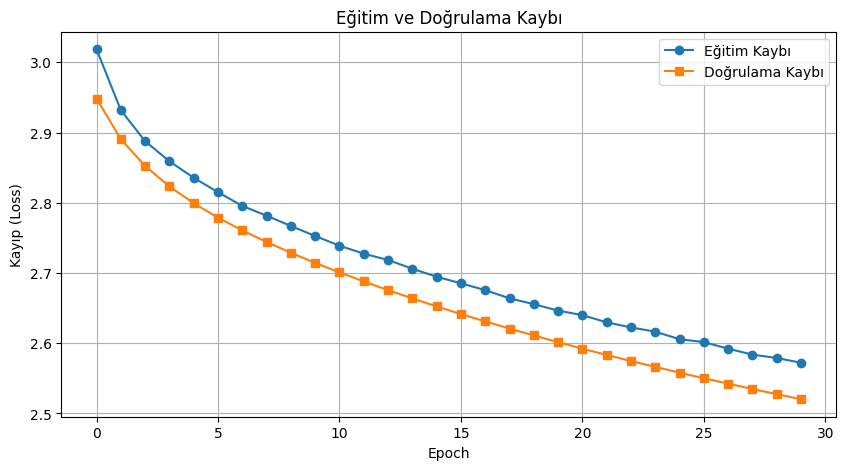

In [8]:
# Modeli eğit

# Hiperparametreler
d_model = 64
num_heads = 4
num_encoder_layers = 2
num_decoder_layers = 2
d_ff = 128
dropout = 0.1
learning_rate = 0.001
num_epochs = 30

# Model oluştur
model = Transformer(
    src_vocab_size=20,
    tgt_vocab_size=20,
    d_model=d_model,
    num_heads=num_heads,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    d_ff=d_ff,
    dropout=dropout
).to(device)

# Loss ve optimizer
criterion = nn.CrossEntropyLoss(ignore_index=0)  # PAD token'ı göz ardı et
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.98), eps=1e-9)

# Learning rate scheduler
def lr_lambda(step):
    """Transformer learning rate scheduler"""
    d_model = 64
    warmup_steps = 4000
    step = max(step, 1)
    return math.pow(d_model, -0.5) * math.pow(step, -0.5)

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Eğitim döngüsü
train_losses = []
val_losses = []

print('=== Eğitim Başlıyor ===\n')

for epoch in range(num_epochs):
    # Eğitim
    model.train()
    epoch_train_loss = 0
    num_batches = 0

    for src, tgt, label in train_loader:
        src, tgt, label = src.to(device), tgt.to(device), label.to(device)

        # İleri besleme
        output = model(src, tgt)

        # Kaybı hesapla
        output = output.view(-1, output.size(-1))
        label = label.view(-1)
        loss = criterion(output, label)

        # Geri yayılım
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()
        scheduler.step()

        epoch_train_loss += loss.item()
        num_batches += 1

    avg_train_loss = epoch_train_loss / num_batches
    train_losses.append(avg_train_loss)

    # Doğrulama
    model.eval()
    epoch_val_loss = 0
    val_batches = 0

    with torch.no_grad():
        for src, tgt, label in val_loader:
            src, tgt, label = src.to(device), tgt.to(device), label.to(device)
            output = model(src, tgt)
            output = output.view(-1, output.size(-1))
            label = label.view(-1)
            loss = criterion(output, label)
            epoch_val_loss += loss.item()
            val_batches += 1

    avg_val_loss = epoch_val_loss / val_batches
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

# Kaybı görselleştir
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Eğitim Kaybı', marker='o')
plt.plot(val_losses, label='Doğrulama Kaybı', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Kayıp (Loss)')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.legend()
plt.grid(True)
plt.show()

## 8. Greedy Decoding ile Çıkarım

Eğitilmiş model ile çıkarım yapma.

**Greedy Decoding:** Her adımda en yüksek olasılıklı token'ı seçme

In [9]:
# Greedy decoding fonksiyonu

def greedy_decode(model, src, max_len=20):
    """Greedy decoding ile çıkarım yapar"""
    model.eval()

    # Kaynak sequence'u encode et
    src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
    src_emb = model.positional_encoding(model.src_embedding(src) * model.scale)
    enc_output = model.encoder(src_emb, src_mask)

    # SOS token'ı ile başla
    tgt = torch.ones(src.size(0), 1, dtype=torch.long, device=device) * 1  # SOS_TOKEN = 1

    for _ in range(max_len):
        # Mevcut hedef sequence'u decode et
        tgt_mask = torch.tril(torch.ones(tgt.size(1), tgt.size(1), device=device)).bool()
        tgt_mask = tgt_mask.unsqueeze(0).unsqueeze(0)

        tgt_emb = model.positional_encoding(model.tgt_embedding(tgt) * model.scale)
        dec_output = model.decoder(tgt_emb, enc_output, src_mask, tgt_mask)
        output = model.output_proj(dec_output)

        # En yüksek olasılıklı token'ı seç
        next_token = output[:, -1, :].argmax(dim=-1, keepdim=True)
        tgt = torch.cat([tgt, next_token], dim=1)

        # EOS token'ı ise dur
        if (next_token == 2).all():  # EOS_TOKEN = 2
            break

    return tgt

# Test örnekleri
print('=== Greedy Decoding Sonuçları ===\n')

model.eval()
test_cases = [
    [3, 4, 5, 6, 7],
    [10, 11, 12, 13],
    [5, 6, 7, 8, 9, 10],
    [15, 14, 13, 12],
    [8, 7, 6, 5, 4, 3],
]

for src_seq in test_cases:
    src_tensor = torch.tensor([src_seq], dtype=torch.long, device=device)
    predicted = greedy_decode(model, src_tensor, max_len=len(src_seq) + 5)
    pred_seq = predicted[0].cpu().tolist()

    # SOS ve EOS token'larını temizle
    pred_clean = [t for t in pred_seq if t not in [0, 1, 2]]

    print(f'Giriş:     {src_seq}')
    print(f'Beklenen:  {src_seq[::-1]}')
    print(f'Tahmin:    {pred_clean}')
    print(f'Doğru mu:  {src_seq[::-1] == pred_clean}')
    print()

=== Greedy Decoding Sonuçları ===

Giriş:     [3, 4, 5, 6, 7]
Beklenen:  [7, 6, 5, 4, 3]
Tahmin:    [5, 5, 5, 3, 5]
Doğru mu:  False

Giriş:     [10, 11, 12, 13]
Beklenen:  [13, 12, 11, 10]
Tahmin:    [4, 12, 11, 4, 12]
Doğru mu:  False

Giriş:     [5, 6, 7, 8, 9, 10]
Beklenen:  [10, 9, 8, 7, 6, 5]
Tahmin:    [5]
Doğru mu:  False

Giriş:     [15, 14, 13, 12]
Beklenen:  [12, 13, 14, 15]
Tahmin:    [14, 12]
Doğru mu:  False

Giriş:     [8, 7, 6, 5, 4, 3]
Beklenen:  [3, 4, 5, 6, 7, 8]
Tahmin:    [5, 11]
Doğru mu:  False



## 9. Attention Görselleştirilmesi

Modelin hangi bölgelere odaklandığını görselleştiriyoruz.

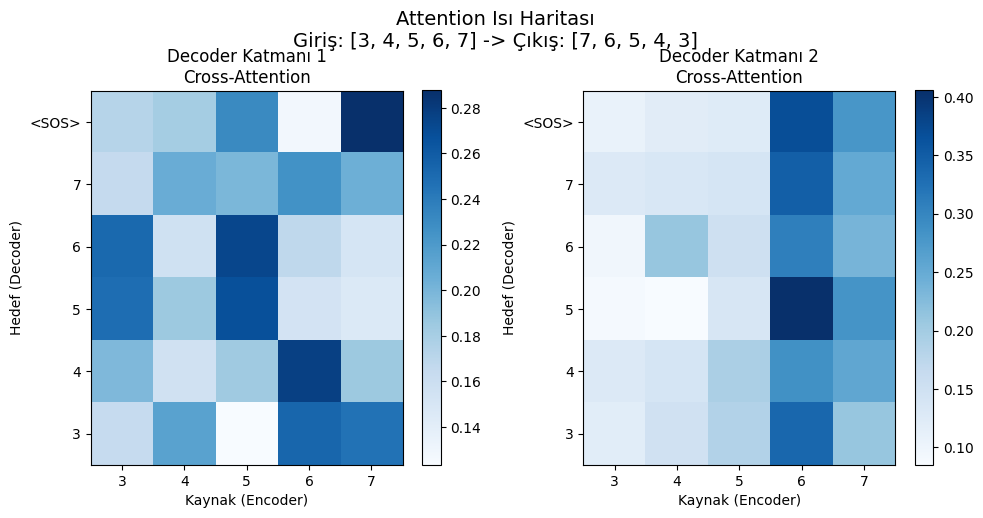


=== Attention Analizi ===
Katman 1, Hedef "<SOS>" -> En çok dikkat: "7"
Katman 1, Hedef "7" -> En çok dikkat: "6"
Katman 1, Hedef "6" -> En çok dikkat: "5"
Katman 1, Hedef "5" -> En çok dikkat: "5"
Katman 1, Hedef "4" -> En çok dikkat: "6"
Katman 1, Hedef "3" -> En çok dikkat: "6"
Katman 2, Hedef "<SOS>" -> En çok dikkat: "6"
Katman 2, Hedef "7" -> En çok dikkat: "6"
Katman 2, Hedef "6" -> En çok dikkat: "6"
Katman 2, Hedef "5" -> En çok dikkat: "6"
Katman 2, Hedef "4" -> En çok dikkat: "6"
Katman 2, Hedef "3" -> En çok dikkat: "6"


In [10]:
# Attention ağırlıklarını çıkar ve görselleştir

def get_attention_weights(model, src, tgt):
    """Decoder'daki cross-attention ağırlıklarını çıkarır"""
    model.eval()

    # Encoder
    src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
    src_emb = model.positional_encoding(model.src_embedding(src) * model.scale)
    enc_output = model.encoder(src_emb, src_mask)

    # Decoder - cross-attention ağırlıklarını al
    tgt_mask = torch.tril(torch.ones(tgt.size(1), tgt.size(1), device=device)).bool()
    tgt_mask = tgt_mask.unsqueeze(0).unsqueeze(0)

    tgt_emb = model.positional_encoding(model.tgt_embedding(tgt) * model.scale)

    # Decoder katmanlarındaki cross-attention'ı al
    attention_weights = []
    x = tgt_emb
    for layer in model.decoder.layers:
        # Self-attention
        attn_output, _ = layer.self_attn(x, x, x, tgt_mask)
        x = layer.norm1(x + layer.dropout1(attn_output))

        # Cross-attention
        attn_output, attn_w = layer.cross_attn(x, enc_output, enc_output, src_mask)
        attention_weights.append(attn_w.detach())
        x = layer.norm2(x + layer.dropout2(attn_output))

    return attention_weights

# Örnek attention görselleştirme
src_seq = [3, 4, 5, 6, 7]
src_tensor = torch.tensor([src_seq], dtype=torch.long, device=device)

# Hedef: beklenen ters çevirme
tgt_seq = [1] + src_seq[::-1]  # SOS + ters
tgt_tensor = torch.tensor([tgt_seq], dtype=torch.long, device=device)

# Attention ağırlıklarını al
attn_weights = get_attention_weights(model, src_tensor, tgt_tensor)

# Görselleştir
fig, axes = plt.subplots(1, len(attn_weights), figsize=(5*len(attn_weights), 5))

if len(attn_weights) == 1:
    axes = [axes]

for i, attn in enumerate(attn_weights):
    attn_matrix = attn[0, 0].cpu().numpy()  # İlk batch, ilk kafa

    # Kaynak ve hedef etiketleri
    src_labels = [str(s) for s in src_seq]
    tgt_labels = ['<SOS>'] + [str(s) for s in src_seq[::-1]]

    im = axes[i].imshow(attn_matrix[:len(tgt_labels), :len(src_labels)], cmap='Blues')
    axes[i].set_xticks(range(len(src_labels)))
    axes[i].set_xticklabels(src_labels, fontsize=10)
    axes[i].set_yticks(range(len(tgt_labels)))
    axes[i].set_yticklabels(tgt_labels, fontsize=10)
    axes[i].set_xlabel('Kaynak (Encoder)')
    axes[i].set_ylabel('Hedef (Decoder)')
    axes[i].set_title(f'Decoder Katmanı {i+1}\nCross-Attention')

    plt.colorbar(im, ax=axes[i])

plt.suptitle(f'Attention Isı Haritası\nGiriş: {src_seq} -> Çıkış: {src_seq[::-1]}', fontsize=14)
plt.tight_layout()
plt.show()

# Attention analizi
print('\n=== Attention Analizi ===')
for i, attn in enumerate(attn_weights):
    attn_matrix = attn[0, 0].cpu().numpy()
    # Her hedef token'ı için en çok dikkat edilen kaynak token'ı
    for j in range(min(len(tgt_labels), attn_matrix.shape[0])):
        src_idx = np.argmax(attn_matrix[j, :len(src_labels)])
        print(f'Katman {i+1}, Hedef "{tgt_labels[j]}" -> En çok dikkat: "{src_labels[src_idx]}"')

## 10. Sonuç

Bu notebook'ta Transformer mimarisini sıfırdan uyguladık:

1. **Konumsal Kodlama:** Sinüsözel fonksiyonlarla pozisyon bilgisi ekleme
2. **Multi-Head Attention:** Q, K, V projeksiyonları ve scaled dot-product attention
3. **Feed-Forward Network:** Pozisyon bağımsız dönüşümler
4. **Encoder-Decoder Yapısı:** Residual connections ve layer normalization
5. **Maskeleme:** Source ve target masking (causal)
6. **Veri Hazırlığı:** Sayı dizisi ters çevirme görevi
7. **Eğitim:** Teacher forcing ile eğitim
8. **Greedy Decoding:** Çıkarım yapma
9. **Attention Görselleştirme:** Modelin neye odaklandığını anlama

**Sonraki Adımlar:**
- Daha büyük ve derin modeller deneme
- Gerçek çeviri verileri ile deneme (WMT, OPUS)
- Beam search ve nucleus sampling ekleme
- Multi-task learning (çeviri + sınıflandırma)